# Forward Pass — GP-only vs GP-RSA (Literal) vs GP-RSA (Pragmatic)

Side-by-side comparison of different forward passes given the same training features and GP hyperparameters:

- **GP-only**: training features get hard labels `y=1`, GP predicts P(kind-linked) at test features
- **GP-RSA (Literal)**: RSA literal listener first infers soft labels `y_soft` per training feature, GP then generalises those to test features
- **GP-RSA (Pragmatic)**: Same as above but plugging in pragmatic listener. Not finished running yet (takes a long time)

The only difference between the three is what `y_train` looks like going into the GP.

In [2]:
import sys
sys.path.insert(0, '.')

import pickle
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import importlib

import gp
import rsa as rsa_mod
importlib.reload(gp)
importlib.reload(rsa_mod)

<module 'rsa' from '/Users/mayamalaviya/Documents/PhD/GP Generics/compgenerics/model/gp/rsa.py'>

In [3]:
# load feature set 2d embeddings
with open('../features/set2_features_dataframe.pkl', 'rb') as f:
    df = pickle.load(f)

feat_idx = df.set_index('feature')
print(f"Features loaded: {len(df)}")

Features loaded: 60


In [4]:
# Settings that can be changed
CONDITION  = 'physical'   # 'physical' | 'diet' | 'personality' | 'heterogeneous'
LS         = 1.0          # lengthscale: 0.3, 1.0, 5.0; small → local generalization, large → wide generalization
PRIOR_MEAN = 0.0          # sigmoid(pm) = default coherence; 0 → 0.5

# RSA prior: concentration controls how diffuse the Beta prior over coherence is
RSA_CONCENTRATION = 5.0

# ── Test features (Study 9) ────────────────────────────────────────────────
TEST_FEATURES = [
    'can eat spicy food', 'eat breakfast very late', 'eat five meals a day',
    'like juice with pulp', 'put pepper on all their foods',
    'cry easily', 'like to collect rocks', 'like to dance',
    'like to give high-fives', 'like to read books',
    'can roll their tongue', 'can snap with their toes', 'can wiggle their ears',
    'have cold hands and feet', 'snore when they sleep',
]
X_test = jnp.array([
    feat_idx.loc[f, ['x_2d', 'y_2d']].values for f in TEST_FEATURES
])

# ── Training features for condition ───────────────────────────────────────
masks = {
    'physical':      (df['category'] == 'physical')              & (df['split'] == 'train'),
    'diet':          (df['category'] == 'diet_preferences')      & (df['split'] == 'train'),
    'personality':   (df['category'] == 'personality_behaviors') & (df['split'] == 'train'),
    'heterogeneous': (df['in_heterogenous'] == True)             & (df['split'] == 'train'),
}
train_df = df[masks[CONDITION]]
train_features = list(train_df['feature'])
X_train = jnp.array(train_df[['x_2d', 'y_2d']].values)

kernel_params = jnp.array([1.0, LS, LS])  # (sigma, ls_x, ls_y)

print(f"Condition: {CONDITION}")
print(f"Training features ({len(train_features)}): {train_features}")
print(f"Test features: {len(TEST_FEATURES)}")

Condition: physical
Training features (15): ['can see really far', 'can touch their toes', 'draw circles on their knees', 'have a flat belly button', 'have a loud voice', 'have bony elbows', 'have freckles on their feet', 'have orange earwax', 'have short nails', 'have stripes in their hair', 'have tattoos', 'have wide feet', 'paint their toenails', 'tan easily', 'wear tall socks']
Test features: 15


In [ ]:
# ── GP-only forward pass ───────────────────────────────────────────────────
# All training features get hard label y=1 (definitively kind-linked)
y_hard = jnp.ones(X_train.shape[0]) 
# too similar to old bernoulli representation; in the new representation we don't get these as ones

probs_gp, _, _ = gp.laplace_predict(
    X_train, y_hard, X_test, kernel_params,
    kernel_name='rbf_2d_ard', prior_mean=PRIOR_MEAN
)
probs_gp = np.array(probs_gp)

print("GP-only — P(kind-linked) at test features (y_train = all 1s):")
for feat, p in sorted(zip(TEST_FEATURES, probs_gp), key=lambda x: -x[1]):
    print(f"  {feat:<45} {p:.3f}  {'█' * int(p * 30)}")

GP-only — P(kind-linked) at test features (y_train = all 1s):
  can wiggle their ears                         0.857  █████████████████████████
  have cold hands and feet                      0.856  █████████████████████████
  can snap with their toes                      0.855  █████████████████████████
  can roll their tongue                         0.853  █████████████████████████
  snore when they sleep                         0.850  █████████████████████████
  like to dance                                 0.848  █████████████████████████
  cry easily                                    0.847  █████████████████████████
  like to give high-fives                       0.833  █████████████████████████
  like to read books                            0.833  ████████████████████████
  like to collect rocks                         0.830  ████████████████████████
  eat breakfast very late                       0.824  ████████████████████████
  like juice with pulp                          0.

In [6]:
# ── RSA soft labels ────────────────────────────────────────────────────────
# The RSA pragmatic listener hears a generic utterance for each training feature
# ("Zarpies have [feature]") and infers P(feature i is kind-linked).
# This gives soft labels y_soft in [0, 1] instead of hard 1s.

V = len(train_features)

# Instance: all training features are present
inst_features = rsa_mod.encode(train_features, train_features)  # all-ones (V,)
inst = rsa_mod.Instance(kind='Zarpies', features=inst_features)

# One generic utterance per training feature
data_rsa = [
    (rsa_mod.Utterance(subj=1, feature_idx=i), inst)
    for i in range(V)
]

# Beta prior: derived from GP prior_mean
baseline = float(jax.nn.sigmoid(jnp.array(PRIOR_MEAN)))
alpha = baseline * RSA_CONCENTRATION
beta  = (1.0 - baseline) * RSA_CONCENTRATION

post = rsa_mod.literal_listener(data_rsa, train_features, alpha=alpha, beta=beta)

masks_rsa = np.array(post['hyp_masks'])  # (2^V, V)
weights    = np.array(post['weights'])        # (2^V,)
y_soft     = np.array([(weights * masks_rsa[:, i]).sum() for i in range(V)])

print("RSA soft labels — P(kind-linked) per training feature:")
for feat, ys in sorted(zip(train_features, y_soft), key=lambda x: -x[1]):
    print(f"  {feat:<45} {ys:.3f}  {'█' * int(ys * 30)}")

RSA soft labels — P(kind-linked) per training feature:
  can see really far                            0.992  █████████████████████████████
  can touch their toes                          0.992  █████████████████████████████
  draw circles on their knees                   0.992  █████████████████████████████
  have a flat belly button                      0.992  █████████████████████████████
  have a loud voice                             0.992  █████████████████████████████
  have bony elbows                              0.992  █████████████████████████████
  have freckles on their feet                   0.992  █████████████████████████████
  have orange earwax                            0.992  █████████████████████████████
  have short nails                              0.992  █████████████████████████████
  have stripes in their hair                    0.992  █████████████████████████████
  have tattoos                                  0.992  █████████████████████████████
  have wid

In [7]:
# ── GP-RSA forward pass ────────────────────────────────────────────────────
# Same GP call, but y_train = soft RSA labels instead of hard 1s
probs_rsa, _, _ = gp.laplace_predict(
    X_train, jnp.array(y_soft), X_test, kernel_params,
    kernel_name='rbf_2d_ard', prior_mean=PRIOR_MEAN
)
probs_rsa = np.array(probs_rsa)

print("GP-RSA — P(kind-linked) at test features (y_train = RSA soft labels):")
for feat, p in sorted(zip(TEST_FEATURES, probs_rsa), key=lambda x: -x[1]):
    print(f"  {feat:<45} {p:.3f}  {'█' * int(p * 30)}")

GP-RSA — P(kind-linked) at test features (y_train = RSA soft labels):
  can wiggle their ears                         0.852  █████████████████████████
  have cold hands and feet                      0.851  █████████████████████████
  can snap with their toes                      0.850  █████████████████████████
  can roll their tongue                         0.848  █████████████████████████
  snore when they sleep                         0.845  █████████████████████████
  like to dance                                 0.843  █████████████████████████
  cry easily                                    0.842  █████████████████████████
  like to give high-fives                       0.828  ████████████████████████
  like to read books                            0.827  ████████████████████████
  like to collect rocks                         0.825  ████████████████████████
  eat breakfast very late                       0.818  ████████████████████████
  like juice with pulp                     

In [ ]:
# ── Pragmatic listener soft labels ────────────────────────────────────────
# L1: speaker model is nested inside, so this is slower (2^V * 2^V).
# Uses same data_rsa, alpha, beta as the literal listener above.
# WARNING: slow for V > 10. For physical (V=15), expect several minutes.

post_prag   = rsa_mod.pragmatic_listener(data_rsa, train_features, alpha=alpha, beta=beta)

masks_prag  = np.array(post_prag['hyp_masks'])  # (2^V, V)
weights_prag = np.array(post_prag['weights'])    # (2^V,)
y_soft_prag  = np.array([(weights_prag * masks_prag[:, i]).sum() for i in range(V)])

print("Pragmatic listener soft labels — P(kind-linked) per training feature:")
for feat, ys in sorted(zip(train_features, y_soft_prag), key=lambda x: -x[1]):
    print(f"  {feat:<45} {ys:.3f}  {'█' * int(ys * 30)}")

In [ ]:
# ── GP-RSA (pragmatic) forward pass ───────────────────────────────────────
probs_rsa_prag, _, _ = gp.laplace_predict(
    X_train, jnp.array(y_soft_prag), X_test, kernel_params,
    kernel_name='rbf_2d_ard', prior_mean=PRIOR_MEAN
)
probs_rsa_prag = np.array(probs_rsa_prag)

print("GP-RSA (pragmatic) — P(kind-linked) at test features:")
for feat, p in sorted(zip(TEST_FEATURES, probs_rsa_prag), key=lambda x: -x[1]):
    print(f"  {feat:<45} {p:.3f}  {'█' * int(p * 30)}")

/var/folders/qb/4f5th4w557qd4b1rmp7v8lxm0000gq/T/ipykernel_1520/5061326.py:29: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax.scatter(np.array(X_train)[:, 0], np.array(X_train)[:, 1],


NameError: name 'probs_rsa_prag' is not defined

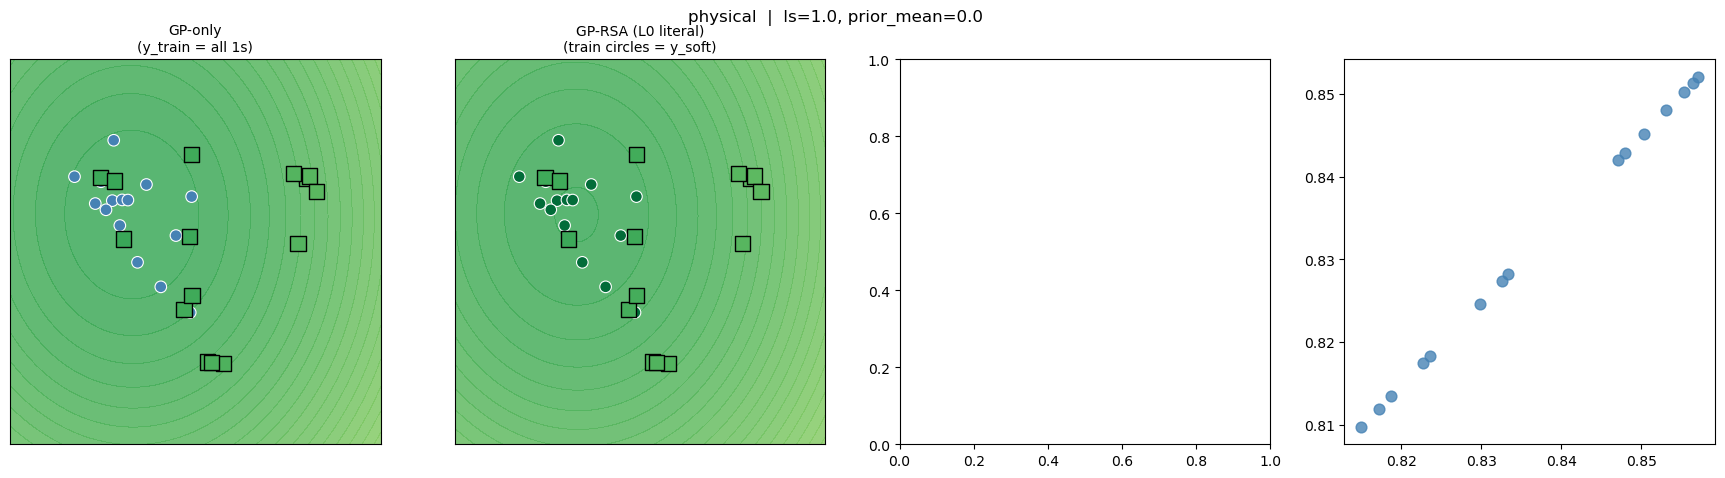

In [10]:
# ── Side-by-side visualization: GP-only | GP-RSA (L0) | GP-RSA (L1) ──────
GRID_RES = 60

all_x = np.concatenate([np.array(X_train)[:, 0], np.array(X_test)[:, 0]])
all_y = np.concatenate([np.array(X_train)[:, 1], np.array(X_test)[:, 1]])
pad = 0.2
xx, yy = np.meshgrid(
    np.linspace(all_x.min() - pad, all_x.max() + pad, GRID_RES),
    np.linspace(all_y.min() - pad, all_y.max() + pad, GRID_RES),
)
grid_pts = jnp.array(np.stack([xx.ravel(), yy.ravel()], axis=1))

def gp_surface(y_tr):
    p, _, _ = gp.laplace_predict(
        X_train, jnp.array(y_tr), grid_pts, kernel_params,
        kernel_name='rbf_2d_ard', prior_mean=PRIOR_MEAN
    )
    return np.array(p).reshape(xx.shape)

surface_gp   = gp_surface(y_hard)
surface_lit  = gp_surface(y_soft)
# surface_prag = gp_surface(y_soft_prag)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle(f'{CONDITION}  |  ls={LS}, prior_mean={PRIOR_MEAN}', fontsize=12)

def draw_heatmap(ax, surface, train_colors, test_colors, title):
    ax.contourf(xx, yy, surface, levels=20, cmap='RdYlGn', vmin=0, vmax=1, alpha=0.85)
    ax.scatter(np.array(X_train)[:, 0], np.array(X_train)[:, 1],
               c=train_colors, cmap='RdYlGn', vmin=0, vmax=1,
               s=70, edgecolors='white', linewidths=0.8, zorder=4)
    sc = ax.scatter(np.array(X_test)[:, 0], np.array(X_test)[:, 1],
                    c=test_colors, cmap='RdYlGn', vmin=0, vmax=1,
                    s=120, marker='s', edgecolors='black', linewidths=1.0, zorder=5)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    return sc

# Panel 1: GP-only (train = blue, all y=1)
draw_heatmap(axes[0], surface_gp,
             train_colors=['steelblue'] * len(train_features),
             test_colors=probs_gp,
             title='GP-only\n(y_train = all 1s)')

# Panel 2: GP-RSA L0 (train colored by y_soft_lit)
draw_heatmap(axes[1], surface_lit,
             train_colors=y_soft,
             test_colors=probs_rsa,
             title='GP-RSA (L0 literal)\n(train circles = y_soft)')

# # Panel 3: GP-RSA L1 (train colored by y_soft_prag)
# sc = draw_heatmap(axes[2], surface_prag,
#                   train_colors=y_soft_prag,
#                   test_colors=probs_rsa_prag,
#                   title='GP-RSA (L1 pragmatic)\n(train circles = y_soft)')
# plt.colorbar(sc, ax=axes[2], label='P(kind-linked)')

# Panel 4: scatter — all three sets of test predictions
ax = axes[3]
ax.scatter(probs_gp, probs_rsa,      s=60, alpha=0.8, label='GP-only vs L0', color='steelblue')
ax.scatter(probs_gp, probs_rsa_prag, s=60, alpha=0.8, label='GP-only vs L1', color='tomato', marker='s')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('GP-only prediction')
ax.set_ylabel('GP-RSA prediction')
ax.set_title('GP-only vs GP-RSA\n(above line = RSA pushed higher)', fontsize=10)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()